---
tags: [algorithm, optimization, variational]
---

# Alternating Operator Ansatzによるグラフ彩色問題

このチュートリアルでは、Qamomile を用いて **K-グラフ彩色問題** を Alternating Operator Ansatz, 略してAOA で解く方法を紹介します。

>Hadfield, S.; Wang, Z.; O'Gorman, B.; Rieffel, E.G.; Venturelli, D.; Biswas, R. From the Quantum Approximate Optimization Algorithm to a Quantum Alternating Operator Ansatz. Algorithms 2019, 12, 34. https://doi.org/10.3390/a12020034

AOA アルゴリズムは、より一般的なミキサー (mixer) と初期状態を用いることで QAOA を拡張したものです。

### なぜこれがグラフ彩色問題で重要なのか？
ワンホット符号化では $N \times K$ 個の二値変数を用いますが、$2^{NK}$ 個のビット列のうち
実行可能なものは $K^N$ 個しかありません（各ノードに 1 つの色）。
以下で扱う 5 ノード・3 色のインスタンスでは、$2^{15} = 32768$ 次元のヒルベルト空間の中に
実行可能状態は 243 個しかなく、すなわち全体の $1\%$ 未満です。
標準的な QAOA は空間全体に対する一様な重ね合わせから出発し、横磁場ミキサー
($\sum X_i$) を用いますが、これは量子ビットを自由に実行可能部分空間の内外へ回転させてしまうため、
サンプリングされるビット列のほとんどはワンホット制約に違反して破棄されることになります。
AOA はこの両端の問題を解決します。すなわち、実行可能部分空間の内部から出発し、
ハミング重みを保存する XY ミキサーを用いることで、サンプルは構成上すべて実行可能になります。

以下の手順で進めていきます：

1. [JijModeling](https://jij-inc-jijmodeling-tutorials-en.readthedocs-hosted.com/en/latest/introduction.html) で問題を定式化する。
2. 具体的なデータを用いてインスタンスを作成する。
3. `AOAConverter` を使い、指定したミキサーと初期状態で AOA 回路を構築する。
4. 古典オプティマイザで変分パラメータを最適化する。
5. 最適化された回路からサンプリングし、結果をデコードする。QAOA に対する実行可能性の優位性を示します。

In [ ]:
# 最新版の Qamomile を pip でインストールしてください！
# !pip install qamomile

## 問題の定式化

無向グラフ $G = (V, E)$ が与えられたとき、$G$ を与えられた色数 $K$ で彩色し、
$G$ 内で同じ色を持つ隣接頂点の数が最小になるようにすることが目標です。

**目的関数:**

$$
\min \sum_{(u, v) \in E} \sum_{i=0}^{K-1} x_{u, i} x_{v, i}
$$

**制約:**

$$
\sum_{i=0}^{K-1} x_{u, i}=1, \forall u \in\{0, \ldots, N-1\}
$$

ここで $x_{u, i} \in\{0,1\}$ は、頂点 $u$ に色 $i$ が使われている場合 1、そうでなければ 0 となります。

## JijModeling による問題の定義

In [1]:
import jijmodeling as jm


@jm.Problem.define("Graph Coloring", sense=jm.ProblemSense.MINIMIZE)
def graph_coloring_decorated(problem : jm.DecoratedProblem):
    N = problem.Length()
    K = problem.Natural()

    E = problem.Graph()

    x = problem.BinaryVar(
        shape=(N, K),
        description="$x_{i,k}$ is 1 if node $i$ is colored with color $k$, 0 otherwise",
    )

    problem += jm.sum(
        x[u, i] * x[v, i] for (u, v) in E for i in K
    )

    problem += problem.Constraint(
        "ColoringConstraint",
        (jm.sum(x[u, i] for i in K) == 1 for u in N),
        description="Each node must be colored with exactly one color"
    )

graph_coloring_decorated

Problem(name="Graph Coloring", sense=MINIMIZE, objective=sum(E.flat_map(lambda ((u, v): Tuple[natural, natural]): K.map(lambda (i: natural): (u, v, i))).map(lambda ((u, v, i): Tuple[natural, natural, natural]): x[u, i] * x[v, i])), constraints={ColoringConstraint: [Constraint(name="ColoringConstraint", , lambda u: sum(K.map(lambda (i: natural): x[u, i])) == 1, domain=set(N), description="Each node must be colored with exactly one color"),],})

### 制約をハミング重みの条件として読み解く

制約 $\sum_{i=0}^{K-1} x_{u,i} = 1$ は次のことを意味します：ノード $u$ に付随する $K$ 個の二値変数のうち、ちょうど 1 つが $1$ になる。これらをビット列として並べると、各ノードは $K$ 個の連続する量子ビットからなる *ブロック* を占有し、実行可能性とは **各ブロックのハミング重みがちょうど 1 であること** に対応します。

5 ノード・3 色のインスタンスでは、量子ビットの配置は次のようになります：

```
  [q0 q1 q2] [q3 q4 q5] [q6 q7 q8] [q9 q10 q11] [q12 q13 q14]
   node 0     node 1     node 2     node 3        node 4
```

実行可能な状態とは、各括弧で囲まれたブロック内に `1` が 1 つだけある状態のことです。このブロック構造こそが、後ほど登場する `block_size` が指すものです：コンバーターに対して、*各ブロック内で* Dicke 状態を準備し、*各ブロック内でのみ* ミキシングを行うように指示することで、回路の動作中ずっと各ブロックのハミング重みを 1 に保つことができます。

## グラフのインスタンス

再現性のために、辺が 6 本の 5 ノード固定グラフを用います。

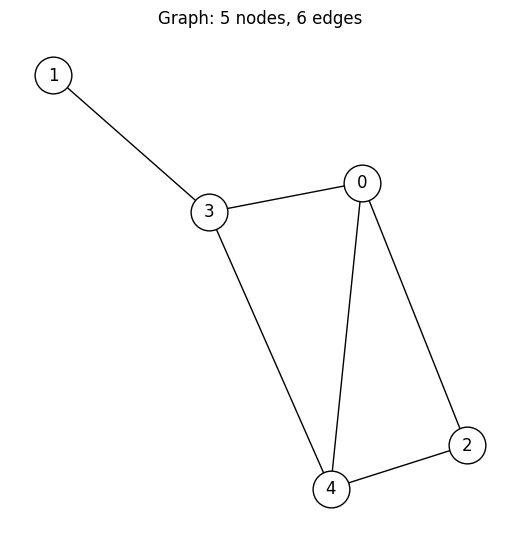

In [2]:
import matplotlib.pyplot as plt
import networkx as nx

num_nodes = 5
edge_list = [(0, 2), (0, 3), (0, 4), (1, 3), (2, 4), (3, 4)]

G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(edge_list)

pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(5, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

## インスタンスの作成

グラフから辺のリストを取り出し、JijModeling の問題に具体的なデータを与えて評価します。

In [3]:
num_colors = 3
instance_data = {"N": num_nodes, "E": edge_list, "K": num_colors}
instance = graph_coloring_decorated.eval(instance_data)

## AOAConverter のセットアップ

`AOAConverter` は OMMX のインスタンスを受け取り、内部で QUBO 形式に変換した上でハミルトニアンを構築します（詳細は QAOA チュートリアルを参照してください）。

注意点：
1. デコードされたサンプルから得られるエネルギー値は、元の目的関数の値とは **異なります**。これは **ペナルティ項** を含んでいます。
2. したがって、真の目的関数の値は別途再計算する必要があります。

In [4]:
from qamomile.optimization.aoa import AOAConverter

converter = AOAConverter(instance)
converter.spin_model = converter.spin_model.normalize_by_abs_max()
hamiltonian = converter.get_cost_hamiltonian()
print(hamiltonian)

Hamiltonian((Z0,): -1.0, (Z1,): -1.0, (Z2,): -1.0, (Z6,): -0.8, (Z9,): -1.0, (Z12,): -1.0, (Z7,): -0.8, (Z10,): -1.0, (Z13,): -1.0, (Z8,): -0.8, (Z11,): -1.0, (Z14,): -1.0, (Z3,): -0.6, (Z4,): -0.6, (Z5,): -0.6, (Z0, Z1): 0.4, (Z0, Z2): 0.4, (Z0, Z6): 0.2, (Z0, Z9): 0.2, (Z0, Z12): 0.2, (Z1, Z2): 0.4, (Z1, Z7): 0.2, (Z1, Z10): 0.2, (Z1, Z13): 0.2, (Z2, Z8): 0.2, (Z2, Z11): 0.2, (Z2, Z14): 0.2, (Z3, Z4): 0.4, (Z3, Z5): 0.4, (Z3, Z9): 0.2, (Z4, Z5): 0.4, (Z4, Z10): 0.2, (Z5, Z11): 0.2, (Z6, Z7): 0.4, (Z6, Z8): 0.4, (Z6, Z12): 0.2, (Z7, Z8): 0.4, (Z7, Z13): 0.2, (Z8, Z14): 0.2, (Z9, Z10): 0.4, (Z9, Z11): 0.4, (Z9, Z12): 0.2, (Z10, Z11): 0.4, (Z10, Z13): 0.2, (Z11, Z14): 0.2, (Z12, Z13): 0.4, (Z12, Z14): 0.4, (Z13, Z14): 0.4)


## 実行可能な回路へのトランスパイル

`converter.transpile()` は QAOA の場合と全く同じように動作します。

さらに、どのような XY ミキサーと初期状態を使うかを選択できます。

初期状態としては、以下の選択肢があります：

- `single_basis_state` : 各ブロック内で正しいハミング重みを持つ計算基底の単一状態（例えば $|100\rangle|100\rangle\ldots$ のように、すべてのノードが最初に色 0 で塗られている状態）。実行可能で決定的、準備コストも低いです。他の実行可能状態へ振幅を広げる役割はミキサーが担います。これは最もシンプルな選択肢であり、まず試してみるのに良い方法です。

- `dicke` : 各ブロックでの Dicke 状態：指定されたハミング重みを持つすべてのビット列に対する等しい重ね合わせ。ハミング重みが 1 でブロックサイズが $K$ の場合、各ブロックは $\frac{1}{\sqrt{K}}(|10\ldots 0\rangle + |01\ldots 0\rangle + \cdots + |0\ldots 01\rangle)$ となるため、初期状態全体が *実行可能空間全体に対する* 一様な重ね合わせになります。準備に追加のゲートを要します（各ブロックあたり $O(K)$ の XY 回転）が、オプティマイザに偏りのない出発点を与えることができます。

- `uniform` : すべての量子ビットにアダマールゲートを適用したもの、すなわち標準的な QAOA の初期状態。**これは実行不可能な状態にも振幅を割り当ててしまう** ため、AOA の実行可能性の保証は失われます。サンプルは通常の QAOA と同様にフィルタリングが必要になります。主にベースラインや、初期状態を比較するアブレーション実験に有用です。

`hamming_weight` パラメータは、各ブロックでの目標ハミング重みを設定します。ワンホット符号化を用いたグラフ彩色問題では常に `1` になります。他の問題（例えば、ちょうど $k$ 個のアイテムを選択する必要がある基数制約付き最適化問題）では、これは異なる値になります。

ミキサーとしては、以下から選択できます：

- `ring` : 各量子ビットをブロック内のサイクル状の 2 つの隣接量子ビットとのみ接続します。*パリティ* 分解（奇数ペア、次に偶数ペア、最後にラップアラウンド）として実装されているため、各層のコストはブロックあたり $O(K)$ の 2 量子ビットゲートとなります。回路は浅くなりますが、振幅がブロック全体に広がるにはより多くの層が必要です。

- `fully-connected` : ブロック内のすべての量子ビットのペアを接続します。*パーティション* 分解（$\binom{K}{2}$ ペアを重ならないラウンドに分割）として実装されているため、各層のコストはブロックあたり $O(K^2)$ の 2 量子ビットゲートとなります。回路は深くなりますが、振幅は単一の層でブロック全体に混合されます。

経験則として：$K$ が大きく回路深さがボトルネックになる場合は `ring` を、$K$ が小さく（例えば $\leq 4$）、より速いミキシングと多様なサンプルが欲しい場合は `fully-connected` を選ぶとよいでしょう。実際、小さなインスタンスでは `fully-connected` の方が 1 ショットあたりにより多くの異なる実行可能解を生成する傾向があります。

`block_size` パラメータは少し理解しにくいかもしれません。
これは Dicke 状態が構築され、ミキサーが適用される各ブロックのサイズを定義するために使われます。
今回のグラフ彩色問題の場合：
- 1 つのノードに対して $K$ 色のいずれかを取り得る $K$ 個の量子ビットがあります。
- 制約は、各ノードが 1 色のみを取り得ることを示しています。したがって、$K$ 個の量子ビットの各部分集合内で、ハミング重み（1 の数）は $1$ に保たれる必要があります。
- `block_size = num_colors` と設定することで、「$K$ 個の量子ビットの各部分集合内で Dicke 状態を準備し、その部分集合内でのみミキシングを行う」と指定しています。

この振る舞いは、次のセクションで `draw` 関数を使って詳しく示します。

In [5]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
p = 5  # AOA の層数

executable_aoa_dicke = converter.transpile(
    transpiler,
    p=p,
    initial_state="dicke",
    hamming_weight=1,
    mixer="fully-connected",
    block_size=num_colors,
)

## AOA 回路の可視化

`Transpiler.to_block` -> `MatplotlibDrawer.draw` パイプラインが適応できないため、qiskitのdrawを使います。

見やすさのために `p=1` を使用します。


In [ ]:
executable = converter.transpile(
    transpiler,
    p=1,
    initial_state="dicke",
    hamming_weight=1,
    mixer="fully-connected",
    block_size=num_colors,
)

fig = executable.quantum_circuit.draw("mpl", fold=-1, scale=2.2)
fig

### 構成要素の確認

少し時間をとってこの回路を説明し、`block_size` の使い方を示しましょう。
この例では `block_size` は $K=3$ （色数）に設定されています。

`aoa_state_dicke` の内部では、複数の qkernel を呼び出しています：

- `prepare_dicke(n,initial_ones,...)` — 最初の列で複数の $X$ ゲートを使い、各ブロックに対して指定されたハミング重みを持つ元の基底状態を作成します。その後、$R_Y$ と CNOT ゲートのシーケンスを使い、各ブロック内で Dicke 状態（同じハミング重みを持つすべての状態の重ね合わせ）を構築します。

- `ising_cost(quad, linear, q, gamma)` — コスト層：QAOA と同じです。$R_Z$ と $R_{ZZ}$ の回転ゲートを使用します。

- `xy_mixer(q, betas[layer], pair_indices_mixer)` — ミキサー層として、CNOT と $R_X$ のゲート群が各ブロックに適用されます。

`aoa_layers(p, ...)` は単に `ising_cost` と `xy_mixer` を交互に並べ、`p` 回繰り返したものです。

In [ ]:
import qamomile.circuit as qmc
from qamomile.circuit.algorithm.aoa import xy_mixer
from qamomile.circuit.algorithm.qaoa import ising_cost
from qamomile.circuit.algorithm.state_preparation import prepare_dicke

# Dicke 状態の準備とミキサーの構築に必要なインデックスを取得するため、コンバーターの内部ロジックにアクセスできます。
# これは可視化には便利ですが、通常のユーザーワークフローの一部ではありません。
initial_ones, schedule_dicke = converter.compute_dicke_composition_schedule(hamming_weight=1, block_size=num_colors)
resolved_pair = converter.resolve_pair_indices(mixer="fully-connected", pair_indices=None, block_size=num_colors)

@qmc.qkernel
def prepare_dicke_measure(
    n: qmc.UInt,
    initial_ones: qmc.Vector[qmc.UInt],
    schedule: qmc.Dict[qmc.Vector[qmc.UInt], qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = prepare_dicke(n, initial_ones, schedule)
    return qmc.measure(q)

executable = transpiler.transpile(
    prepare_dicke_measure,
    bindings={
        "n": converter.spin_model.num_bits,
        "initial_ones": initial_ones,
        "schedule": schedule_dicke,
    },
)

executable.quantum_circuit.draw("mpl", fold=-1, scale=2.2)

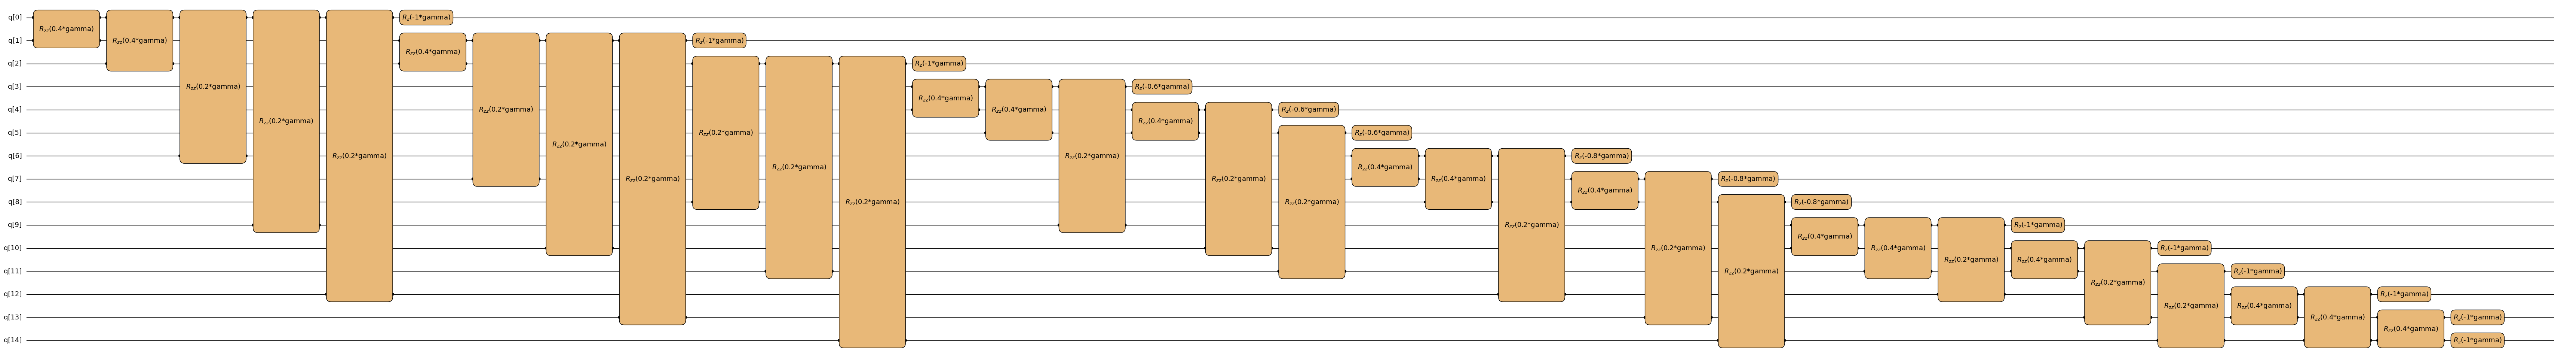

In [8]:
ising_cost.draw(
    q=converter.spin_model.num_bits,
    quad=converter.spin_model.quad,
    linear=converter.spin_model.linear,
    fold_loops=False,
)

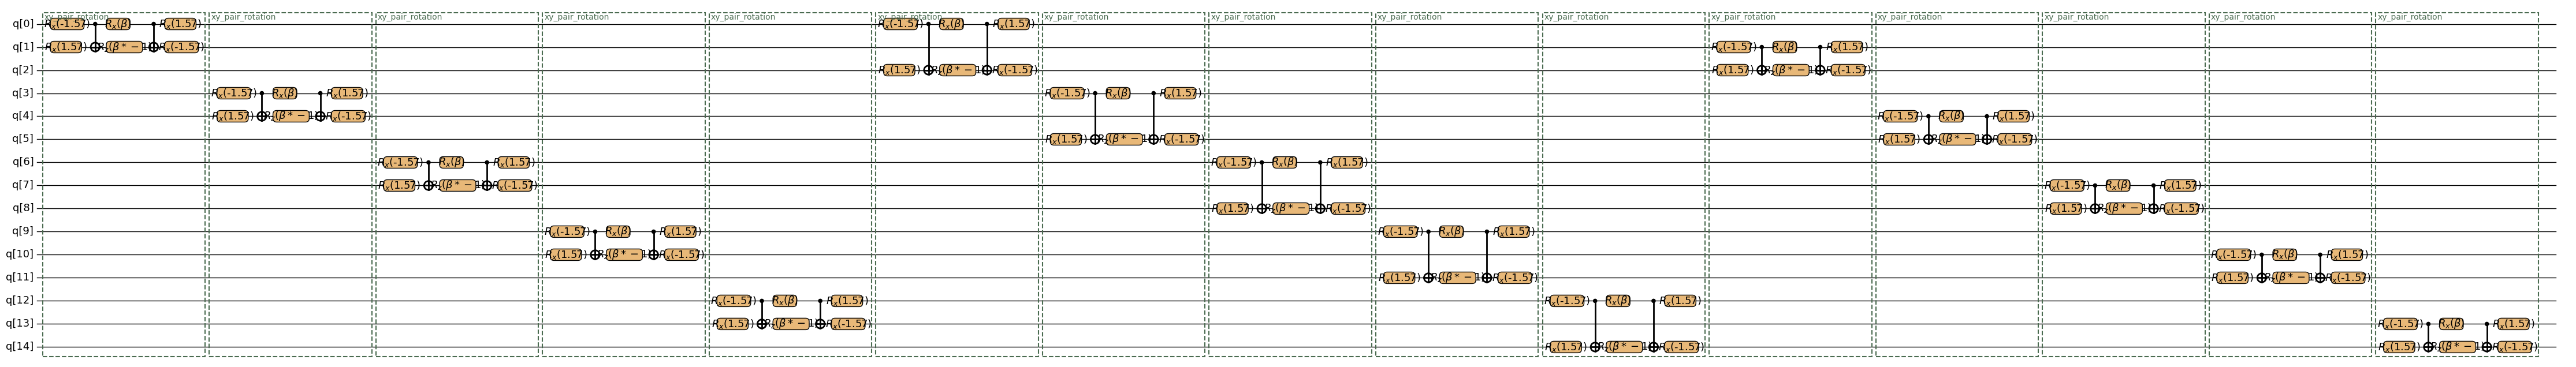

In [9]:
fig = xy_mixer.draw(
    q=converter.spin_model.num_bits,
    pair_indices_mixer=resolved_pair,
    inline=True,
    fold_loops=False,
    expand_composite=True,
    inline_depth=None,
)
fig.set_size_inches(100, 8)
fig

## 交互演算子アンザッツのパラメータ最適化

古典オプティマイザの各イテレーションでコストを評価するために `executable.sample()` を使用します。
オプティマイザはサンプリングされたビット列の平均エネルギーを最小化するように、
異なる `gammas` と `betas` を探索します。

In [10]:
import os

import numpy as np
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

# シミュレータにシードを設定することで、ノートブックを再実行しても
# 同じ COBYLA の最適化経路と最終的なサンプリング分布を再現できます。
# シードがないと、ショットごとに新しいランダム性が生成され、
# COBYLA はノイズの乗ったコスト面を見ることになり、ノートブックの
# 実行ごとに異なる（しかし同等の）局所最適解に収束してしまいます。
executor = transpiler.executor(
    backend=AerSimulator(seed_simulator=901, max_parallel_threads=1)
)
docs_test_mode = os.environ.get("QAMOMILE_DOCS_TEST") == "1"
sample_shots = 256 if docs_test_mode else 2048
maxiter = 25 if docs_test_mode else 1000

rng = np.random.default_rng(900)
initial_params = rng.uniform(0, np.pi, 2 * p)

cost_history = []


def cost_fn(params):
    gammas = list(params[:p])
    betas = list(params[p:])
    job = executable_aoa_dicke.sample(
        executor,
        shots=sample_shots,
        bindings={"gammas": gammas, "betas": betas},
    )
    result = job.result()
    # decode_to_binary_sampleset は QUBO ドメインの BinarySampleSet を返します。
    # この `energy` はペナルティ付きの目的関数値であり、COBYLA が実行不可能性の
    # コストを認識するために必要なものです。多態的な decode() は ommx.v1.SampleSet
    # を返し、その `objective` はペナルティなしの真の目的関数値です。ここでそれを
    # 使うと、オプティマイザが実行不可能な全 0 や全 1 のビット列に落ち着いてしまいます。
    decoded = converter.decode_to_binary_sampleset(result)
    energy = decoded.energy_mean()
    cost_history.append(energy)
    return energy


res = minimize(
    cost_fn,
    initial_params,
    method="COBYLA",
    options={"maxiter": maxiter},
)

print(f"Optimized cost: {res.fun:.3f}")
print(f"Optimal params: {[round(v, 4) for v in res.x]}")
print(f"Function evaluations: {res.nfev}")

Optimized cost: 1.466
Optimal params: [np.float64(0.9317), np.float64(1.008), np.float64(2.7131), np.float64(1.4831), np.float64(3.5131), np.float64(1.5391), np.float64(3.48), np.float64(0.4127), np.float64(1.7299), np.float64(0.9596)]
Function evaluations: 84


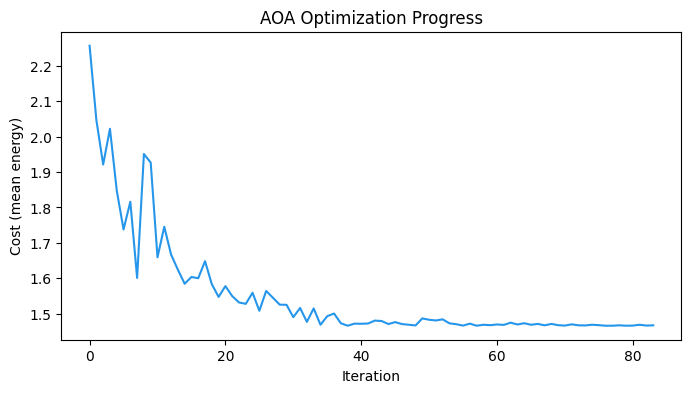

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(cost_history, color="#2696EB")
plt.xlabel("Iteration")
plt.ylabel("Cost (mean energy)")
plt.title("AOA Optimization Progress")
plt.show()

## 最適化されたパラメータでのサンプリング

最適化されたパラメータを使って回路をサンプリングし、
ビット列として候補解を収集します。

In [12]:
gammas_opt = list(res.x[:p])
betas_opt = list(res.x[p:])

sample_result = executable_aoa_dicke.sample(
    executor,
    shots=1000,
    bindings={"gammas": gammas_opt, "betas": betas_opt},
).result()

# OMMX を内部で利用するコンバーターでの `decode()` は、*元の*（ペナルティなしの）
# インスタンスに対して評価された `ommx.v1.SampleSet` を返します。
# したがって、実行可能性、真の目的関数値、制約ごとの診断情報は、
# OMMX 自身の API を通じて利用可能であり、独自の実行可能性判定や
# 目的関数計算のヘルパーを書く必要はありません。
sample_set = converter.decode(sample_result)

## 結果の分析

### 実行可能性のチェック

ここで、QAOA に対する AOA の優位性を確認できます。

私たちが実装した問題に合わせた XY ミキサーは、
実行可能空間の中に留まることを可能にするはずです。したがって、
QAOA の場合とは異なり、AOA によって提案される **候補解** はすべて
実行可能空間内に存在するはずです。
つまり、ハミング重み $=1$ の制約を満たしていることになります。

In [13]:
summary = sample_set.summary
total_feasible = int(summary["feasible"].sum())
total_samples = len(summary)

print(
    f"Feasible samples: {total_feasible} / {total_samples} "
    f"({100 * total_feasible / total_samples:.1f}%)"
)

Feasible samples: 1000 / 1000 (100.0%)


### 最良の実行可能解

`SampleSet.best_feasible` は、目的関数値が最も良い（ここでは最も小さい）
実行可能サンプルを返します。

In [14]:
best = sample_set.best_feasible
df = best.decision_variables_df
x_rows = df[df["name"] == "x"]

best_coloring = {}
for _, row in x_rows.iterrows():
    node, color = row["subscripts"]
    if row["value"] > 0.5:
        best_coloring[int(node)] = int(color)

print("Best coloring:", best_coloring)
print("Number of Conflicts (neighbor nodes with the same color):", int(round(best.objective)))

Best coloring: {0: 2, 1: 2, 2: 1, 3: 1, 4: 0}
Number of Conflicts (neighbor nodes with the same color): 0


### 目的関数値の分布

真の目的関数値（衝突数）の分布をプロットします。

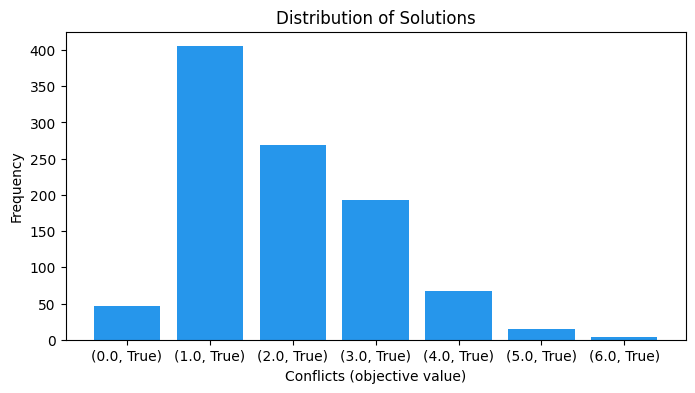

In [15]:
obj_counts = summary.value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar([str(o) for o in obj_counts.index], obj_counts.values, color="#2696EB")
plt.xlabel("Conflicts (objective value)")
plt.ylabel("Frequency")
plt.title("Distribution of Solutions")
plt.show()

### 最良の 3 彩色の可視化

交互演算子アンザッツアルゴリズムで見つかった最良の実行可能彩色に従って、グラフのノードを色付けします。

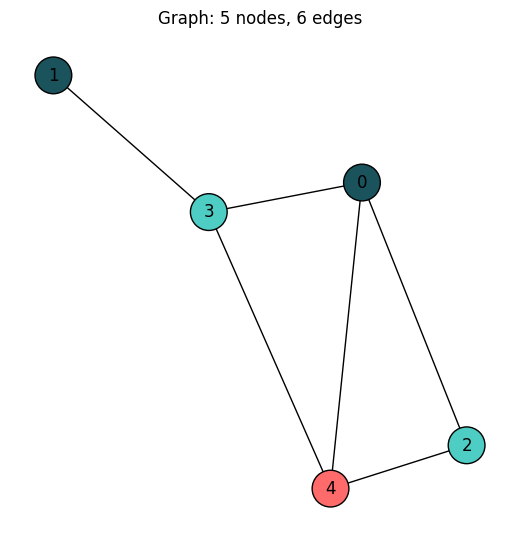

In [16]:
def get_color_map_from_solution(best_coloring, num_colors):
    """ 最良の解に対するカラーマップを作成します。"""

    colors = ["#FF6B6B", "#4ECDC4", "#1A535C"]
    color_map = []
    for u in range(num_nodes):
        color_idx = best_coloring.get(u, 0)  # ノードが見つからない場合は 0 をデフォルトとする
        color_map.append(colors[color_idx])
    return color_map

color_map = get_color_map_from_solution(best_coloring, num_colors)

pos = nx.spring_layout(G, seed=1)
plt.figure(figsize=(5, 5))
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=color_map if color_map else "white",
    node_size=700,
    edgecolors="black",
)
plt.title(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
plt.show()

## まとめ

このチュートリアルでは以下を行いました：

1. JijModeling で K 彩色問題をモデル化しました。各ノードに 1 つのワンホット変数を割り当て、
   各ノードにハミング重み 1 の制約を課し、`BinaryModel` でIsingモデルへ変換しました。
2. `AOAConverter` を使って交互演算子アンザッツを構築しました。コスト層は QAOA と同じ
   Ising コスト層ですが、ミキサーには XY ミキサー、初期状態には Dicke 状態を使うことで、
   すべてのサンプルがワンホットの可行部分空間に留まるようにしました。
3. `prepare_dicke`、`ising_cost`、`xy_mixer` といった構成要素と、`block_size` が
   レジスタをノードごとの Dicke ブロックに分割する仕組みを確認しました。
4. サンプリングした平均エネルギーに対して `gammas` と `betas` を最適化し、最適化後の回路を
   サンプリングして OMMX の `SampleSet` にデコードすることで、可行性のチェックと
   最良の彩色の可視化を行いました。

AOA の初期状態とミキサーがワンホット制約をあらかじめ満たすように設計されているため、
サンプリングされるすべてのビット列は構成上常に可行となります。オプティマイザは
隣接ノード間の衝突数を最小化することだけに専念できます。